# 4.5 상관관계

## 4.5.1 피어슨 상관계수

- 두 특징 사이의 선형(linear) 상관관계의 세기(강도)를 의미하는 [-1, +1] 구간의 수치로, 흔히 $r$로 표기
- **선형** 은 두 특징의 상관관계가 얼마나 강한지 하나의 직선으로 서술할 수 있음을 의미함
    - 한 특징이 일정한 양이 증가한 만큼 다른 특징도 증가하면 +1
    - 반대의 경우에는 -1
    - 상관계수 0은 두 특징이 연관되어 있지 않아서 서로 독립적임을 의미함
    - 두 특징이 비선형 종속 관계일 때도 0인 경우가 있지만 드문 경우임

- 피어슨 상관계수의 공식:
$$
    \text{corr}(X,Y)=\frac
    {\text{E}(X,Y)-\text{E}(X)\text{E}(Y)}
    {
        \sqrt{\text{E}(X^2)-\text{E}(X)^2}
        \sqrt{\text{E}(Y^2)-\text{E}(Y)^2}
    }
$$

- $\text{E}(X)$는 $X$의 **기댓값(expectation)**. 기댓값은 평균과 동일함
- 피어슨 상관계수 함수:
```
def pearson(x, y):
    exy = (x*y).mean()
    ex = x.mean()
    ey = y.mean()
    exx = (x*x).mean()
    ex2 = x.mean()**2
    eyy = (y*y).mean()
    ey2 = y.mean()**2
    return (exy - ex*ey)/(np.sqrt(exx-ex2)*np.sqrt(eyy-ey2))
```

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# pearson() 함수 구현
def pearson(x, y):
    exy = (x*y).mean()
    ex = x.mean()
    ey = y.mean()
    exx = (x*x).mean()
    ex2 = x.mean()**2
    eyy = (y*y).mean()
    ey2 = y.mean()**2
    return (exy - ex*ey)/(np.sqrt(exx-ex2)*np.sqrt(eyy-ey2))

In [3]:
# Numpy와 Sccipy의 피어슨 상관계수 함수들과 pearson 함수 비교

np.random.seed(8675309)
N = 100
x = np.linspace(0,1,N) + (np.random.random(N)-0.5)
y = np.random.random(N)*x
z = -0.1*np.random.random(N)*x

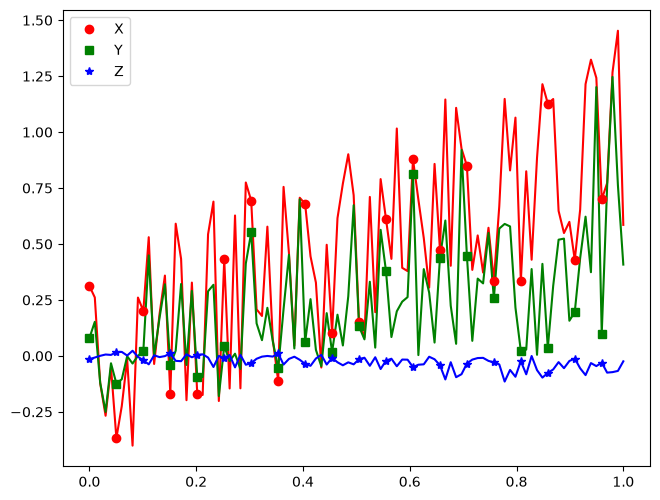

In [4]:
plt.plot(np.linspace(0,1,N),x,color='r')
plt.plot(np.linspace(0,1,N),y,color='g')
plt.plot(np.linspace(0,1,N),z,color='b')
plt.plot(np.linspace(0,1,N)[::5],x[::5],color='r',marker='o',linestyle='none',label='X')
plt.plot(np.linspace(0,1,N)[::5],y[::5],color='g',marker='s',linestyle='none',label='Y')
plt.plot(np.linspace(0,1,N)[::5],z[::5],color='b',marker='*',linestyle='none',label='Z')
plt.legend(loc="upper left")
plt.tight_layout(pad=0, w_pad=0, h_pad=0)
# plt.savefig("correlation_xyz_plot.png", dpi=300)
plt.show()

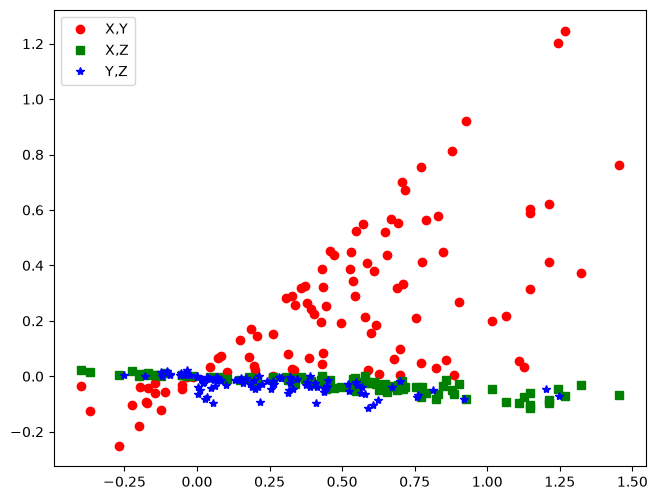

In [5]:
plt.plot(x,y,marker='o',linestyle='none',color='r',label="X,Y")
plt.plot(x,z,marker='s',linestyle='none',color='g',label="X,Z")
plt.plot(y,z,marker='*',linestyle='none',color='b',label="Y,Z")
plt.legend(loc="upper left")
plt.tight_layout(pad=0, w_pad=0, h_pad=0)
# plt.savefig("correlation_scatter_plot.png", dpi=300)
plt.show()

In [6]:
# 직접 구현 결과
print(f"pearson(x,y): {pearson(x,y):.6f}")
print(f"pearson(x,z): {pearson(x,z):.6f}")
print(f"pearson(y,z): {pearson(y,z):.6f}")

pearson(x,y): 0.682852
pearson(x,z): -0.850475
pearson(y,z): -0.565361


In [7]:
# Numpy: np.corrcoef()
d = np.vstack((x,y,z))
print(np.corrcoef(d))

[[ 1.          0.68285166 -0.85047468]
 [ 0.68285166  1.         -0.56536104]
 [-0.85047468 -0.56536104  1.        ]]


In [8]:
# Scipy: stats.pearsonr()
from scipy.stats import pearsonr

print(f"pearson(x,y): {pearsonr(x,y)[0]:.6f}")
print(f"pearson(x,z): {pearsonr(x,z)[0]:.6f}")
print(f"pearson(y,z): {pearsonr(y,z)[0]:.6f}")

pearson(x,y): 0.682852
pearson(x,z): -0.850475
pearson(y,z): -0.565361


In [9]:
# 이미지 데이터에서 상관관계
from sklearn.datasets import load_sample_image

china = load_sample_image('china.jpg')
a = china[230,:,1].astype("float64")
b = china[231,:,1].astype("float64")
c = china[400,:,1].astype("float64")
d = np.random.random(640)

print(f"china(a,b): {pearson(a,b):.6f}")
print(f"china(a,c): {pearson(a,c):.6f}")
print(f"china(a,d): {pearson(a,d):.6f}")

china(a,b): 0.897929
china(a,c): -0.276064
china(a,d): -0.067170


## 4.5.2 스피어먼 상관계수

- 피어슨 상관계수와 동일하게 [-1, +1] 구간의 값이며, $p$로 표기
- 특징 값들 자체가 아닌 특징 값들의 순위(rank)에 기초
- 만약 변수 X가 아래와 같을 때:
$$
    [86, 62, 28, 43, 3, 92, 38, 87, 74, 11]
$$
- 순위는 다음과 같다:
$$
    [7, 5, 2, 4, 0, 9, 3, 8, 6, 1]
$$

- 피어슨 상관은 선형 관계를 찾고, 스피어만 상관은 입력들 사이의 단조적(monotonic) 연관 관계를 찾음
- 스피어만 상관계수의 공식은 다음과 같다:
$$
    p=1-\bigg(
            \frac{6}{n(n^2-1)}
        \bigg)
        \sum_{i=0}^{n-1}d_i^2
$$
- 여기서 $n$은 값들의 개수이고 $d=\text{rank}{X}-\text{rank}{Y}$는 짝지은 $X$값과 $Y$값의 순위 차이이다
- 위 식은 순위들이 고유할 때만 유효함
- 스피어만 상관관계 함수:
```
def spearman(x,y):
    n = len(x)
    t = x[np.argsort(x)]
    rx = []
    for i in range(n):
        rx.append(np.where(x[i] == t)[0][0])
    rx = np.array(rx, dtype="float64")
    t = y[np.argsort(y)]
    ry = []
    for i in range(n):
        ry.append(np.where(y[i] == t)[0][0])
    ry = np.array(ry, dtype="float64")
    d = rx - ry
    return 1.0 - (6.0/(n*(n*n-1)))*(d**2).sum()
```


In [10]:
# spearman() 함수 구현
def spearman(x,y):
    n = len(x)
    t = x[np.argsort(x)]
    rx = []
    for i in range(n):
        rx.append(np.where(x[i] == t)[0][0])
    rx = np.array(rx, dtype="float64")
    t = y[np.argsort(y)]
    ry = []
    for i in range(n):
        ry.append(np.where(y[i] == t)[0][0])
    ry = np.array(ry, dtype="float64")
    d = rx - ry
    return 1.0 - (6.0/(n*(n*n-1)))*(d**2).sum()

In [11]:
# 직접 구현 vs. Scipy 비교

from scipy.stats import spearmanr

print(spearman(x,y), spearmanr(x,y)[0])
print(spearman(x,z), spearmanr(x,z)[0])
print(spearman(y,z), spearmanr(y,z)[0])

0.694017401740174 0.6940174017401739
-0.8950855085508551 -0.895085508550855
-0.6414041404140414 -0.6414041404140414


In [12]:
# 피어슨과 스피어만의 차이
## 기울어진 직선(ramp)과 S자형 함수의 상관관계
## 두 함수 모두 x가 증가함에 따라 더 큰 양수를 산출하지만, 둘의 상관관계가 순수하게 선형적이지 않음

ramp = np.linspace(-20,20,1000)
sig = 1.0 / (1.0 + np.exp(-ramp))
print(pearson(ramp,sig))
print(spearman(ramp,sig))

0.9053277293366915
1.0
